# CEO Social Capital — Research Summary

Full multi-factor overview of the **CEO_SC** research pipeline: does a CEO's position in the executive/director social network (BoardEx) predict company stock returns?

This notebook visualises the outputs of `scripts/06` through `scripts/12`:

- **13 raw social-capital factors**: degree/eigenvector centrality, PageRank, structural holes (effective size), network constraint, and brokerage measure — each under two point-in-time edge conventions ("**cumulative**": all-time connections, "**active**": currently-live connections) — plus raw connection count (`n_unique_connected`).
- **3 PCA composite factors** (`pc1_rank`/`pc2_rank`/`pc3_rank`) that collapse the above 13 (highly correlated) factors into a smaller set of orthogonal "tradable" signals.

For every factor: cross-sectional IC/Rank IC, quantile portfolios, long-short and long-only portfolio performance, and Fama-MacBeth regression validation (univariate + multivariate).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120

OUT = '../data/processed'

CATEGORY_PALETTE = {
    'Cumulative': 'steelblue',
    'Active': 'darkorange',
    'PCA composite': 'seagreen',
    'Connection count': 'grey',
}

def factor_category(name: str) -> str:
    if name.startswith('pc'):
        return 'PCA composite'
    if name == 'n_unique_connected_rank':
        return 'Connection count'
    if '_active_' in name:
        return 'Active'
    return 'Cumulative'

def factor_prefix(factor: str, primary: str = 'n_unique_connected_rank') -> str:
    return '' if factor == primary else f'{factor}_'

## 1. Factor Landscape: IC & Long-Short Performance Across All Factors

In [2]:
fc = pd.read_csv(os.path.join(OUT, 'factor_comparison.csv')).set_index('factor')
fr = pd.read_csv(os.path.join(OUT, 'factor_regression_comparison.csv')).set_index('factor')
landscape = fc.join(fr)
landscape['category'] = [factor_category(f) for f in landscape.index]
landscape = landscape.sort_values('long_short_sharpe', ascending=False)
landscape.round(4)

,mean_ic,mean_rank_ic,rank_icir,long_short_sharpe,long_short_ann_return,long_short_max_drawdown,out_of_sample_r2,mean_coef,t_stat,p_value,category
factor,,,,,,,,,,,
eigenvector_centrality_rank,0.0083,0.0075,0.1231,0.3747,0.0801,-0.1135,-0.0000,0.0808,1.7982,0.0721,Cumulative
degree_centrality_active_rank,0.0119,0.0283,0.7358,0.3122,0.0725,-0.1364,-0.0028,0.0748,1.6500,0.0990,Active
eigenvector_centrality_active_rank,0.0001,0.0103,0.1623,0.2945,0.0591,-0.1284,-0.0027,0.0537,1.3291,0.1838,Active
degree_centrality_rank,0.0110,0.0244,0.6240,0.2766,0.0682,-0.1973,-0.0015,0.0782,1.5540,0.1202,Cumulative
pc2_rank,0.0028,-0.0090,-0.2724,0.2686,0.0186,-0.1733,-0.0023,0.0340,1.3597,0.1739,PCA composite
brokerage_measure_active_rank,0.0114,0.0286,0.7744,0.2120,0.0392,-0.3528,-0.0022,0.0358,0.9842,0.3250,Active
pc1_rank,0.0083,0.0283,0.6809,0.1863,0.0435,-0.4147,-0.0024,0.0520,0.9269,0.3540,PCA composite
brokerage_measure_rank,0.0001,0.0101,0.2848,0.1832,0.0450,-0.3410,-0.0031,0.0397,0.7617,0.4462,Cumulative
n_unique_connected_rank,0.0027,0.0180,0.3459,0.1791,0.0466,-0.3060,-0.0026,0.0481,0.7876,0.4309,Connection count


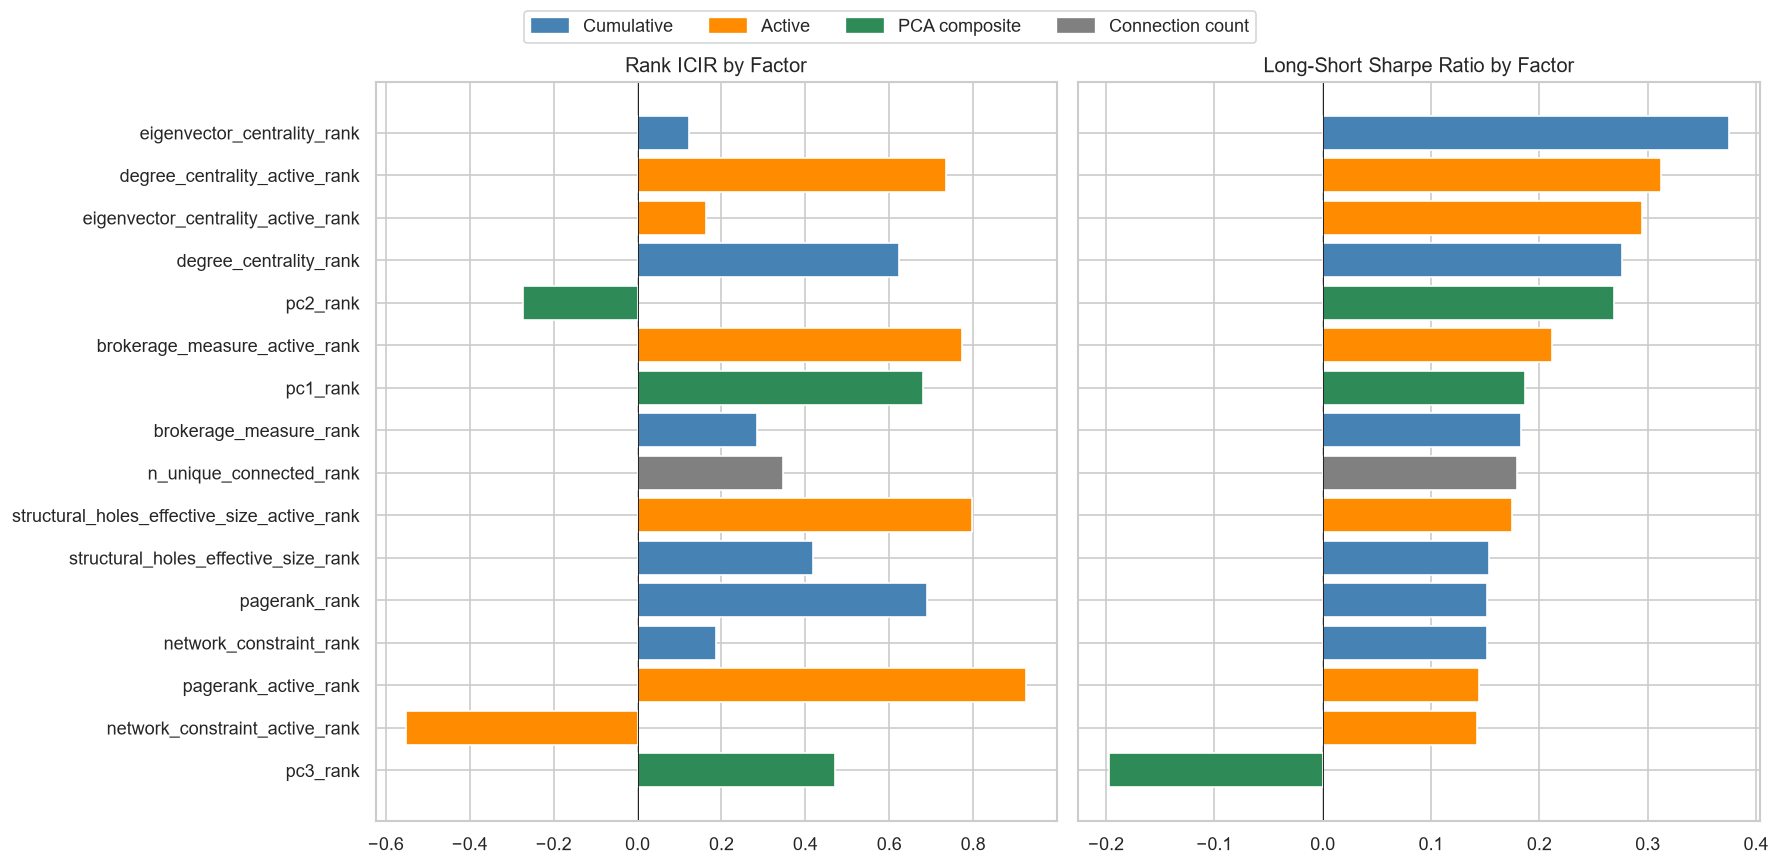

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
colors = landscape['category'].map(CATEGORY_PALETTE)

ax = axes[0]
ax.barh(landscape.index, landscape['rank_icir'], color=colors)
ax.set_title('Rank ICIR by Factor')
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()

ax = axes[1]
ax.barh(landscape.index, landscape['long_short_sharpe'], color=colors)
ax.set_title('Long-Short Sharpe Ratio by Factor')
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()
ax.set_yticklabels([])

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in CATEGORY_PALETTE.values()]
fig.legend(handles, CATEGORY_PALETTE.keys(), loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.04))
plt.tight_layout()
plt.show()

## 2. Deep Dive: Best Individual Factor (by Long-Short Sharpe)

Best factor by long-short Sharpe: eigenvector_centrality_rank (Sharpe=0.37, ann. return=8.01%)


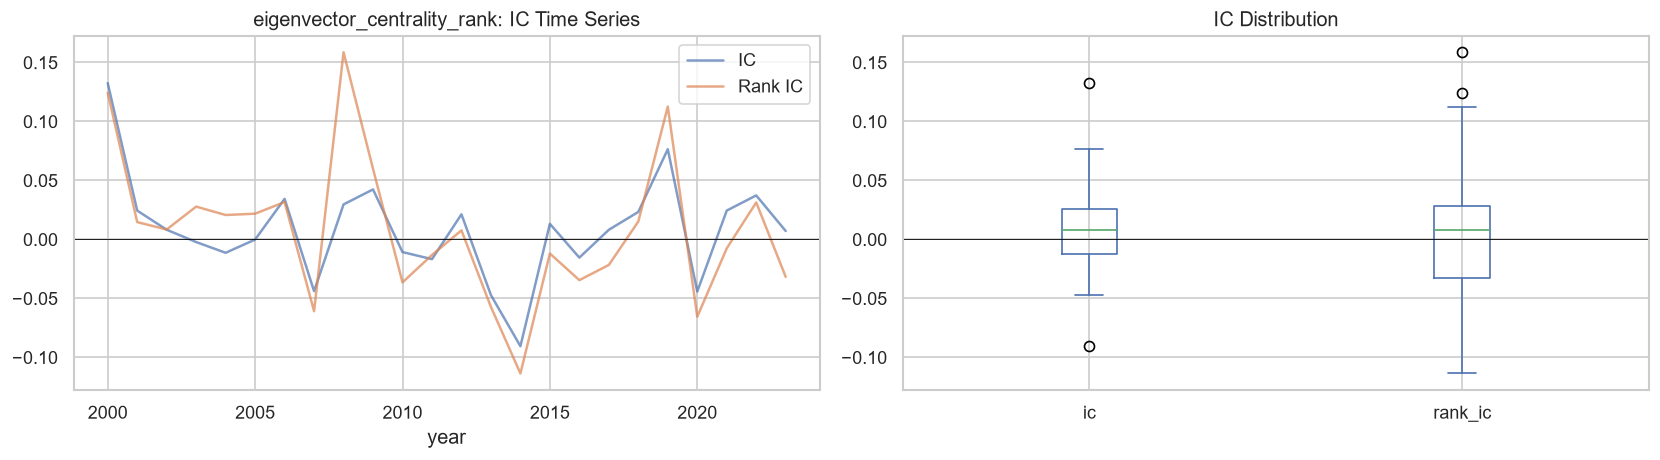

In [4]:
best_factor = landscape['long_short_sharpe'].idxmax()
prefix = factor_prefix(best_factor)
print(f"Best factor by long-short Sharpe: {best_factor} "
      f"(Sharpe={landscape.loc[best_factor, 'long_short_sharpe']:.2f}, "
      f"ann. return={landscape.loc[best_factor, 'long_short_ann_return']:.2%})")

ic = pd.read_csv(os.path.join(OUT, f'{prefix}ic_timeseries.csv'), index_col=0)
ic.index.name = 'year'

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ic['ic'].plot(ax=ax, label='IC', alpha=0.7)
ic['rank_ic'].plot(ax=ax, label='Rank IC', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title(f'{best_factor}: IC Time Series')
ax.legend()

ax = axes[1]
ic.plot(kind='box', ax=ax)
ax.set_title('IC Distribution')
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

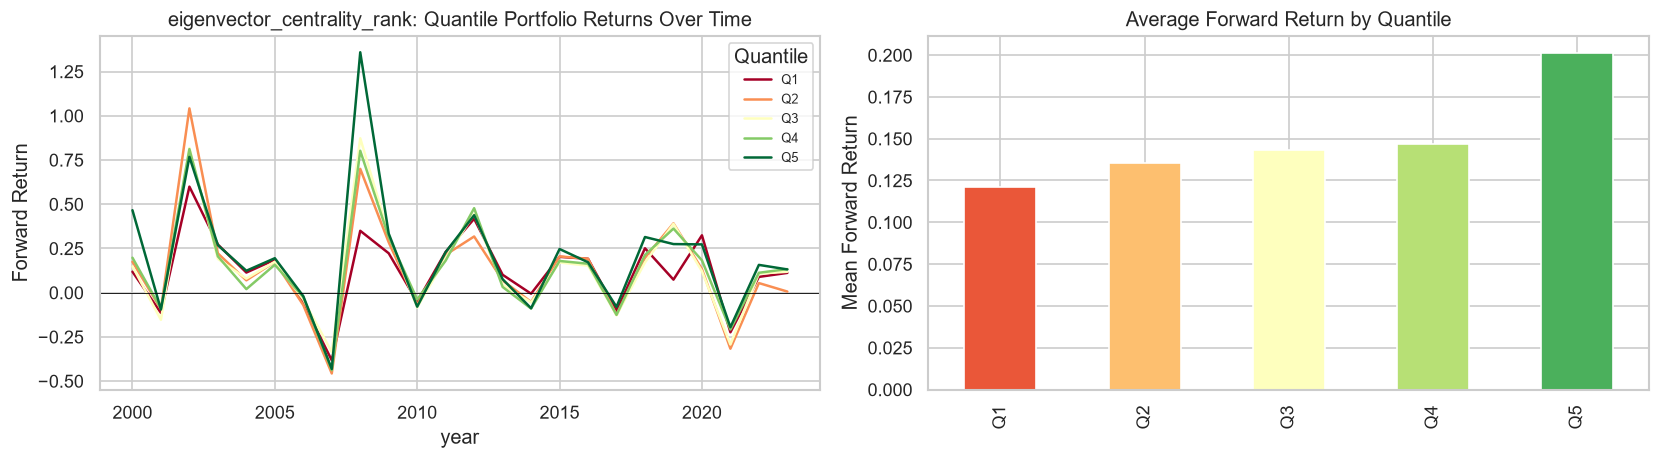

In [5]:
quantiles = pd.read_csv(os.path.join(OUT, f'{prefix}quantile_returns.csv'), index_col=0)
quantiles.index.name = 'year'
quantiles.columns = [f'Q{int(float(c))}' for c in quantiles.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
quantiles.plot(ax=ax, cmap='RdYlGn')
ax.set_title(f'{best_factor}: Quantile Portfolio Returns Over Time')
ax.set_ylabel('Forward Return')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(title='Quantile', fontsize=8)

ax = axes[1]
quantiles.mean().plot(kind='bar', ax=ax, color=sns.color_palette('RdYlGn', n_colors=len(quantiles.columns)))
ax.set_title('Average Forward Return by Quantile')
ax.set_ylabel('Mean Forward Return')
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

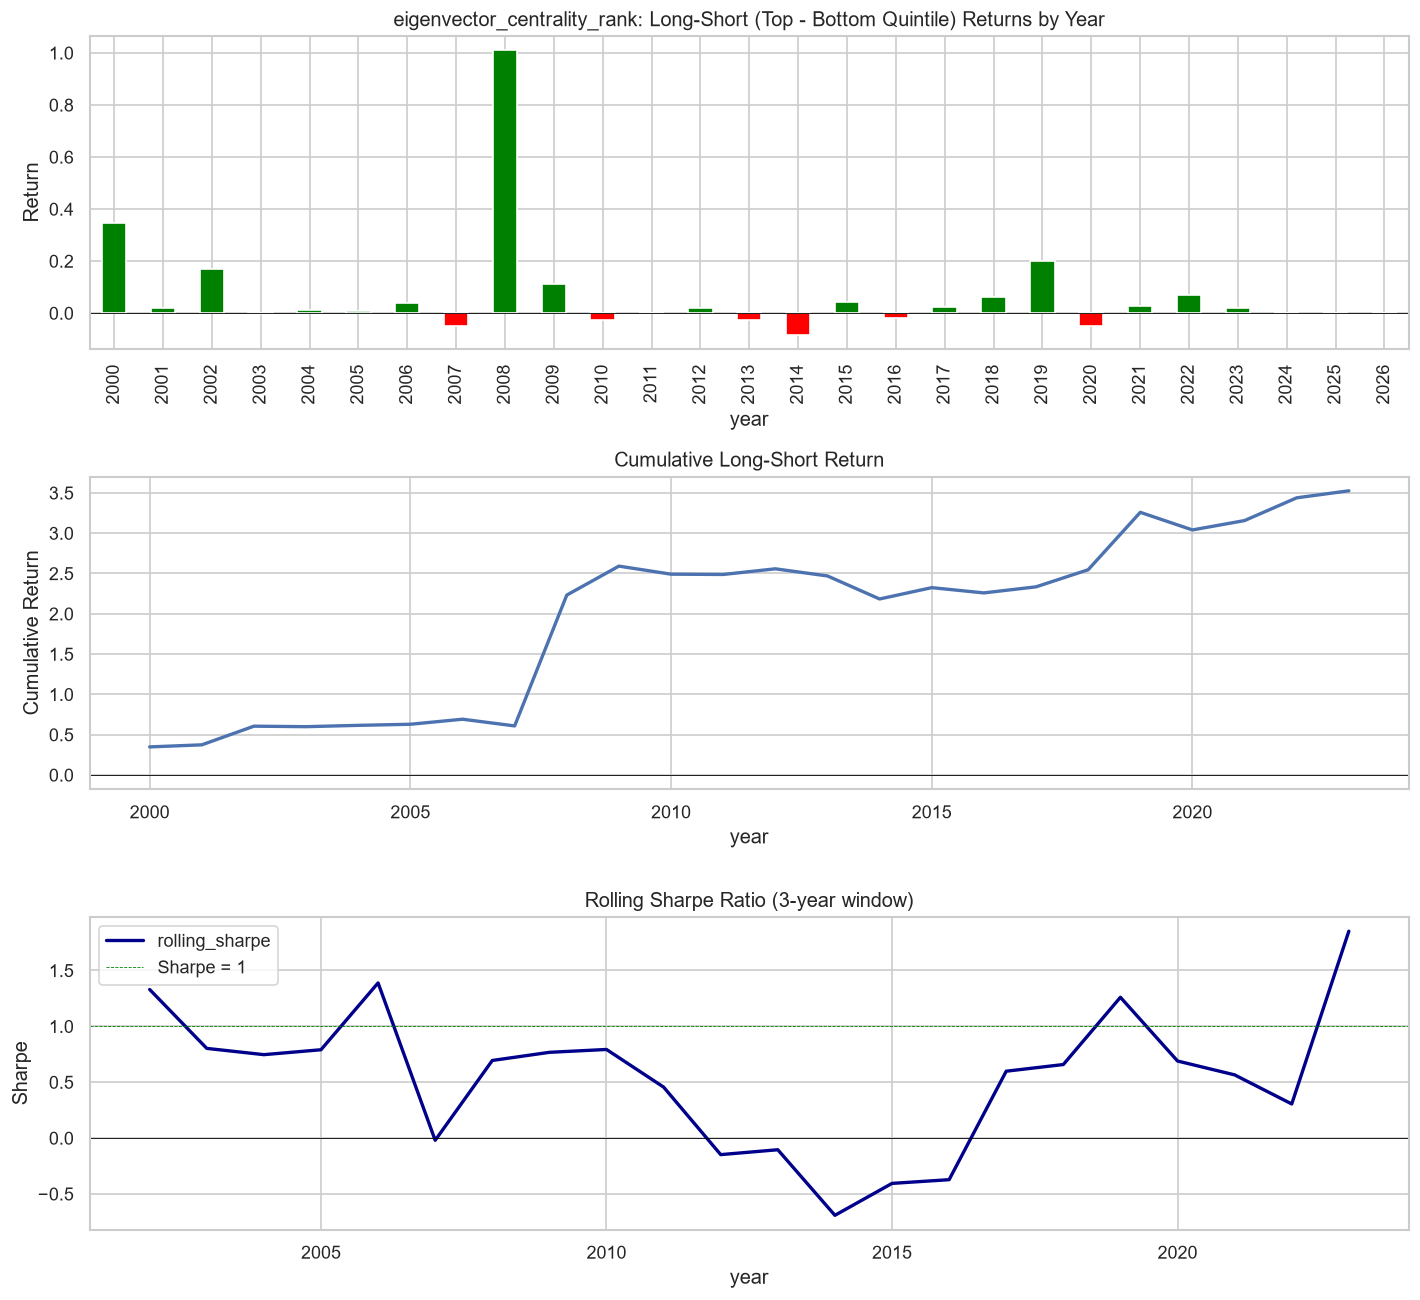

Total cumulative return: nan%
Annualized return:       8.01%
Annualized volatility:   21.36%
Sharpe ratio:            0.37


In [6]:
ls = pd.read_csv(os.path.join(OUT, f'{prefix}long_short_returns.csv'), index_col=0)
ls.index.name = 'year'
rs = pd.read_csv(os.path.join(OUT, f'{prefix}rolling_sharpe.csv'), index_col=0)
rs.index.name = 'year'

fig, axes = plt.subplots(3, 1, figsize=(12, 11))

ax = axes[0]
colors = ['green' if v > 0 else 'red' for v in ls['long_short']]
ls['long_short'].plot(kind='bar', ax=ax, color=colors)
ax.set_title(f'{best_factor}: Long-Short (Top - Bottom Quintile) Returns by Year')
ax.set_ylabel('Return')
ax.axhline(0, color='black', linewidth=0.5)

ax = axes[1]
cumret = (1 + ls['long_short']).cumprod() - 1
cumret.plot(ax=ax, linewidth=2)
ax.set_title('Cumulative Long-Short Return')
ax.set_ylabel('Cumulative Return')
ax.axhline(0, color='black', linewidth=0.5)

ax = axes[2]
rs['rolling_sharpe'].plot(ax=ax, linewidth=2, color='darkblue')
ax.axhline(0, color='black', linewidth=0.5)
ax.axhline(1, color='green', linewidth=0.5, linestyle='--', label='Sharpe = 1')
ax.set_title('Rolling Sharpe Ratio (3-year window)')
ax.set_ylabel('Sharpe')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Total cumulative return: {cumret.iloc[-1]:.2%}')
print(f'Annualized return:       {ls["long_short"].mean():.2%}')
print(f'Annualized volatility:   {ls["long_short"].std(ddof=0):.2%}')
print(f'Sharpe ratio:            {ls["long_short"].mean() / ls["long_short"].std(ddof=0):.2f}')

## 3. PCA Composite Factors

The 13 raw social-capital factors are highly correlated (see the multivariate Fama-MacBeth in section 4 — no single raw factor survives once the others are controlled for). `scripts/12_build_pca_composite_factors.py` fits PCA on the point-in-time-safe, cross-sectionally standardized factor values to extract a small number of orthogonal composite ("tradable") factors.

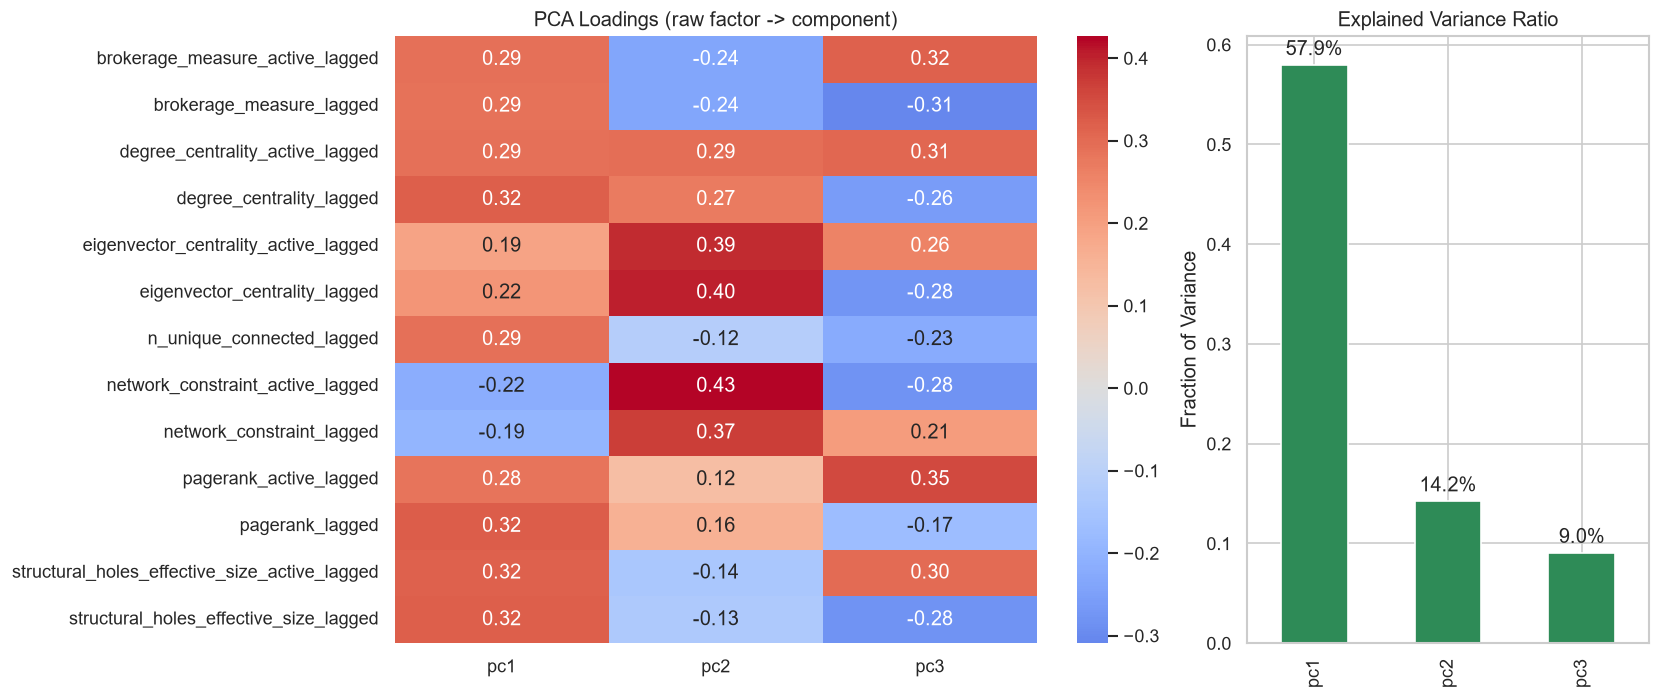

Cumulative variance explained by 3 components: 81.2%


In [7]:
loadings = pd.read_csv(os.path.join(OUT, 'pca_loadings.csv'), index_col=0)
explained = loadings.loc['explained_variance_ratio']
loadings = loadings.drop(index='explained_variance_ratio')

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1]})

ax = axes[0]
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('PCA Loadings (raw factor -> component)')

ax = axes[1]
explained.plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Explained Variance Ratio')
ax.set_ylabel('Fraction of Variance')
for i, v in enumerate(explained):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center')

plt.tight_layout()
plt.show()

print(f"Cumulative variance explained by {len(explained)} components: {explained.sum():.1%}")

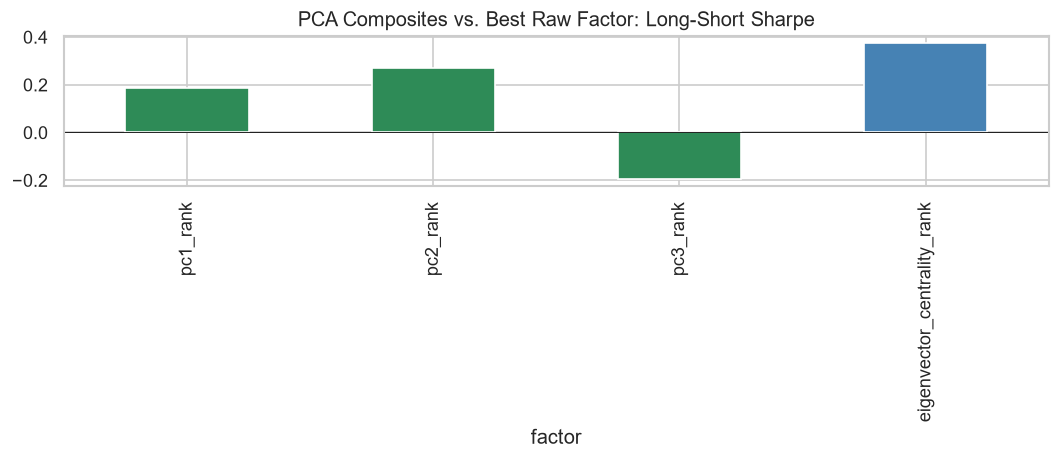

,mean_rank_ic,rank_icir,long_short_sharpe,long_short_ann_return
factor,,,,
pc1_rank,0.0283,0.6809,0.1863,0.0435
pc2_rank,-0.0090,-0.2724,0.2686,0.0186
pc3_rank,0.0177,0.4708,-0.1970,-0.0537
eigenvector_centrality_rank,0.0075,0.1231,0.3747,0.0801


In [8]:
compare_factors = ['pc1_rank', 'pc2_rank', 'pc3_rank', best_factor]
compare = landscape.loc[[f for f in compare_factors if f in landscape.index],
                         ['mean_rank_ic', 'rank_icir', 'long_short_sharpe', 'long_short_ann_return']]

fig, ax = plt.subplots(figsize=(9, 4))
compare['long_short_sharpe'].plot(kind='bar', ax=ax,
                                   color=['seagreen' if f.startswith('pc') else 'steelblue' for f in compare.index])
ax.set_title('PCA Composites vs. Best Raw Factor: Long-Short Sharpe')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

compare.round(4)

## 4. Statistical Validation: Fama-MacBeth

Univariate significance per factor (from `factor_regression_comparison.csv`), and a multivariate specification regressing all 16 factors together (from `fama_macbeth_multivariate.csv`) to see which remain significant once controlling for the others.

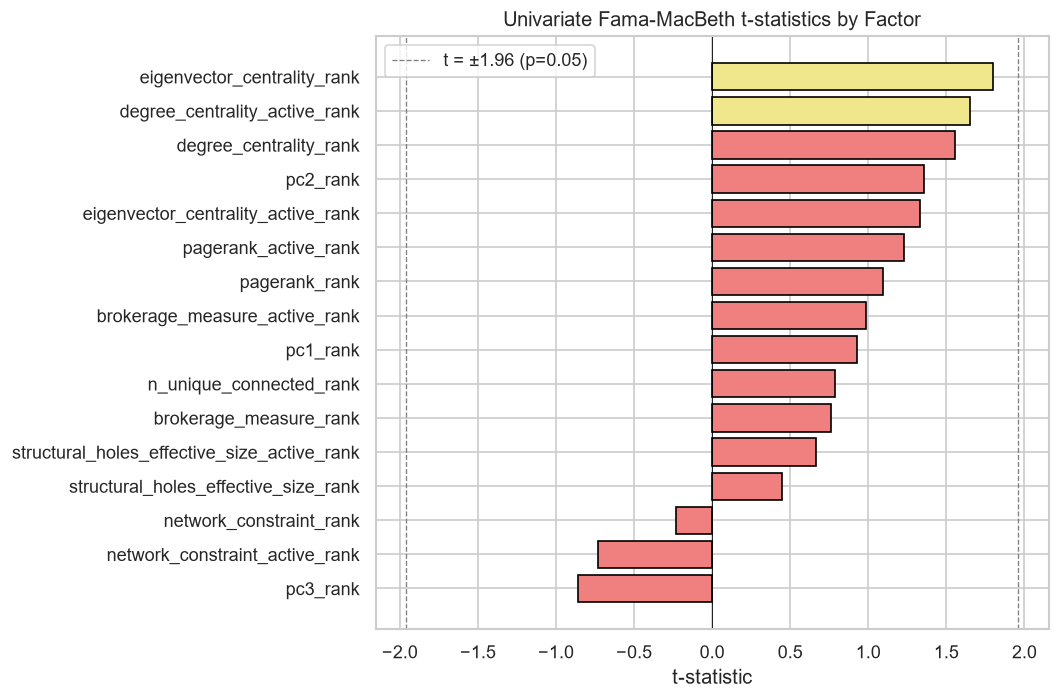

,mean_coef,t_stat,p_value,out_of_sample_r2
factor,,,,
eigenvector_centrality_rank,0.0808,1.7982,0.0721,-0.0000
degree_centrality_active_rank,0.0748,1.6500,0.0990,-0.0028
eigenvector_centrality_active_rank,0.0537,1.3291,0.1838,-0.0027
degree_centrality_rank,0.0782,1.5540,0.1202,-0.0015
pc2_rank,0.0340,1.3597,0.1739,-0.0023
brokerage_measure_active_rank,0.0358,0.9842,0.3250,-0.0022
pc1_rank,0.0520,0.9269,0.3540,-0.0024
brokerage_measure_rank,0.0397,0.7617,0.4462,-0.0031
n_unique_connected_rank,0.0481,0.7876,0.4309,-0.0026


In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
t_stats = landscape['t_stat'].dropna().sort_values()
bar_colors = ['seagreen' if p < 0.05 else ('khaki' if p < 0.10 else 'lightcoral')
              for p in landscape.loc[t_stats.index, 'p_value']]
ax.barh(t_stats.index, t_stats, color=bar_colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.5)
ax.axvline(1.96, color='grey', linewidth=0.8, linestyle='--', label='t = ±1.96 (p=0.05)')
ax.axvline(-1.96, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Univariate Fama-MacBeth t-statistics by Factor')
ax.set_xlabel('t-statistic')
ax.legend()
plt.tight_layout()
plt.show()

landscape[['mean_coef', 't_stat', 'p_value', 'out_of_sample_r2']].round(4)

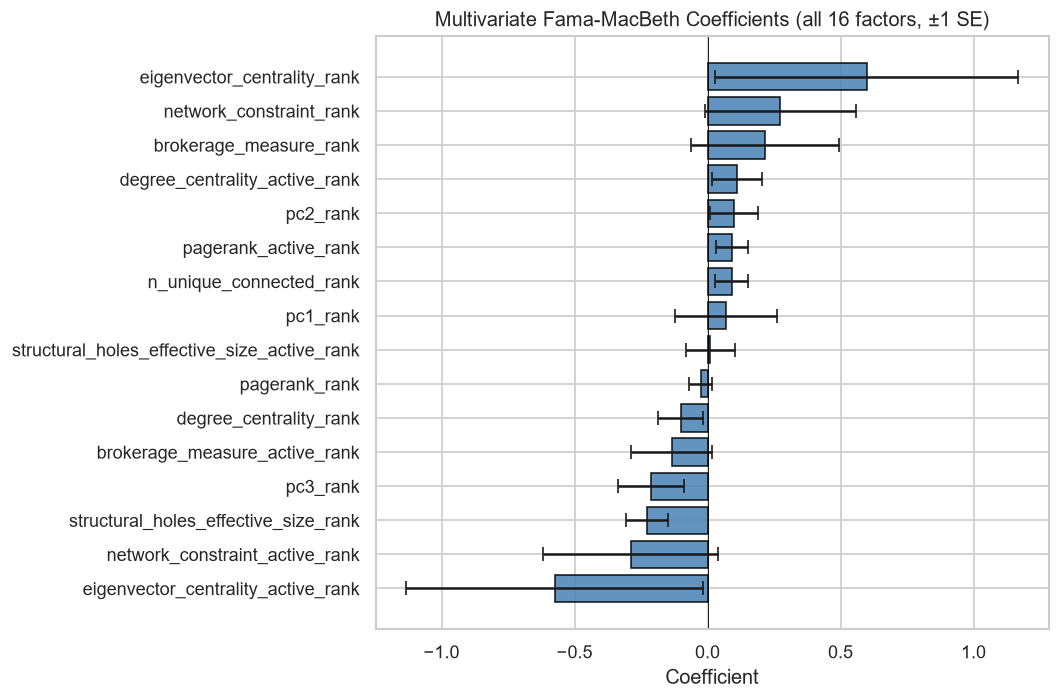

1/16 factors remain significant (p < 0.05) once controlling for all others.


,mean,t_stat,p_value
coefficient,,,
eigenvector_centrality_active_rank,-0.5743,-1.0277,0.3041
network_constraint_active_rank,-0.2890,-0.8780,0.3800
structural_holes_effective_size_rank,-0.2269,-2.9109,0.0036
pc3_rank,-0.2126,-1.6979,0.0895
brokerage_measure_active_rank,-0.1354,-0.8895,0.3737
degree_centrality_rank,-0.1015,-1.1765,0.2394
pagerank_rank,-0.0262,-0.5973,0.5503
structural_holes_effective_size_active_rank,0.0108,0.1188,0.9055
pc1_rank,0.0691,0.3584,0.7200


In [10]:
mv = pd.read_csv(os.path.join(OUT, 'fama_macbeth_multivariate.csv'), index_col=0)
mv_factors = mv.drop(index='const', errors='ignore').sort_values('mean')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(mv_factors.index, mv_factors['mean'], xerr=mv_factors['std_error'],
        color='steelblue', alpha=0.85, edgecolor='black', capsize=4)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Multivariate Fama-MacBeth Coefficients (all 16 factors, ±1 SE)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()

n_sig = (mv_factors['p_value'] < 0.05).sum()
print(f'{n_sig}/{len(mv_factors)} factors remain significant (p < 0.05) once controlling for all others.')
mv_factors[['mean', 't_stat', 'p_value']].round(4)

## 5. Long-Only vs. Long-Short Portfolios

Per-factor long-only (top-quintile) portfolio performance from `long_only_comparison.csv`, compared against the long-short performance from section 1.

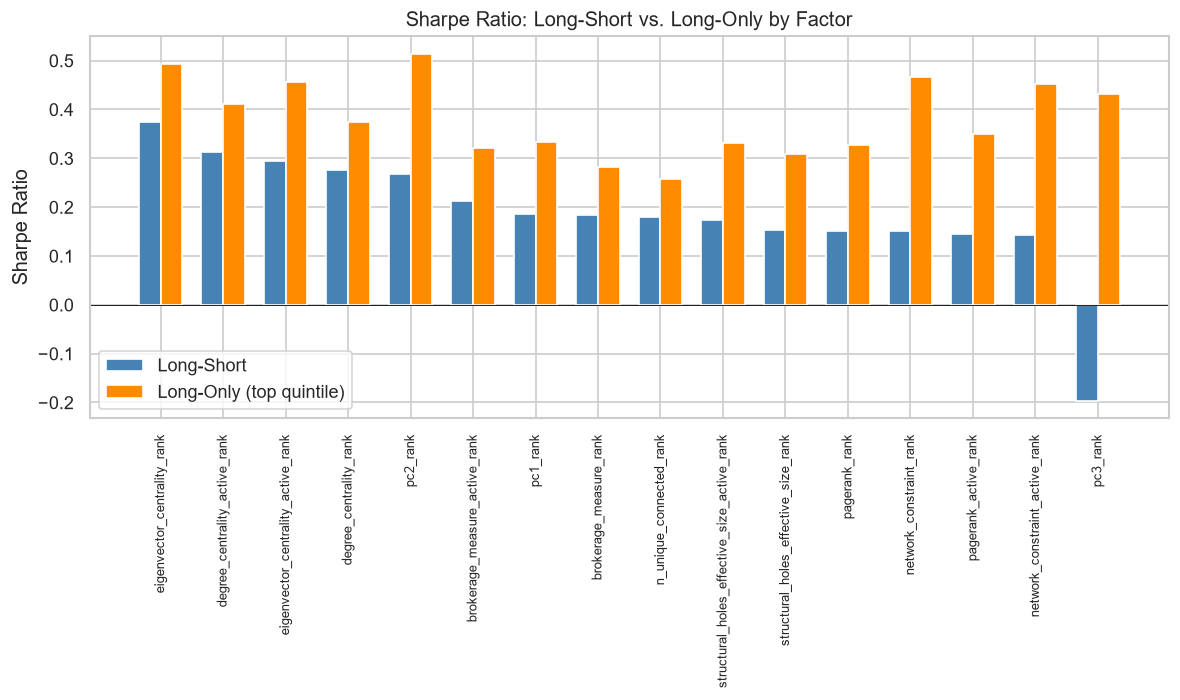

,long_short_sharpe,long_only_sharpe,avg_turnover,max_drawdown
factor,,,,
eigenvector_centrality_rank,0.3747,0.4930,0.1293,-0.0892
degree_centrality_active_rank,0.3122,0.4118,0.1474,-0.1020
eigenvector_centrality_active_rank,0.2945,0.4562,0.2477,-0.1264
degree_centrality_rank,0.2766,0.3748,0.0777,-0.1024
pc2_rank,0.2686,0.5143,0.1947,-0.0635
brokerage_measure_active_rank,0.2120,0.3210,0.1930,-0.1277
pc1_rank,0.1863,0.3328,0.1238,-0.1094
brokerage_measure_rank,0.1832,0.2826,0.0995,-0.1291
n_unique_connected_rank,0.1791,0.2579,0.0930,-0.1288


In [11]:
lo = pd.read_csv(os.path.join(OUT, 'long_only_comparison.csv')).set_index('factor')
combo = landscape[['long_short_sharpe']].join(lo[['sharpe_ratio', 'avg_turnover', 'max_drawdown']],
                                               rsuffix='_long_only')
combo = combo.rename(columns={'sharpe_ratio': 'long_only_sharpe'}).sort_values('long_short_sharpe', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(combo))
width = 0.35
ax.bar(x - width / 2, combo['long_short_sharpe'], width, label='Long-Short', color='steelblue')
ax.bar(x + width / 2, combo['long_only_sharpe'], width, label='Long-Only (top quintile)', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(combo.index, rotation=90, fontsize=8)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Sharpe Ratio: Long-Short vs. Long-Only by Factor')
ax.set_ylabel('Sharpe Ratio')
ax.legend()
plt.tight_layout()
plt.show()

combo.round(4)

## 6. Whole-Universe Benchmark Portfolio

Factor-agnostic equal/value-weighted benchmark built by `11_run_econometrics_and_portfolio.py` over the entire universe each year (independent of any social-capital signal) — a baseline for turnover and risk.

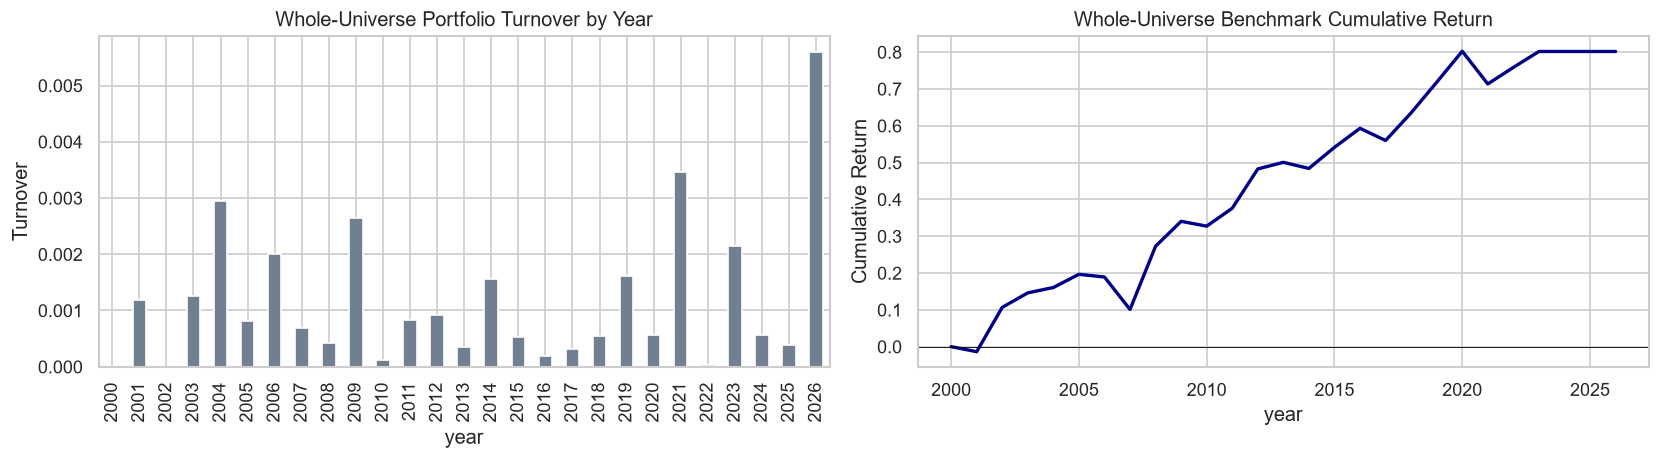

Average turnover: 0.0012
Risk metrics: {'volatility_annualized': np.float64(0.0462), 'downside_deviation_annualized': np.float64(0.0236), 'value_at_risk_95': np.float64(-0.0408), 'conditional_var_95': np.float64(-0.0617)}


In [12]:
import sys
sys.path.insert(0, '../src')
from ceo_sc.portfolio.construction import risk_metrics

turnover = pd.read_csv(os.path.join(OUT, 'turnover.csv'), index_col=0)
turnover.index.name = 'year'
attribution = pd.read_csv(os.path.join(OUT, 'performance_attribution.csv'), index_col=0)
attribution.index.name = 'year'

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
turnover['turnover'].plot(kind='bar', ax=ax, color='slategrey')
ax.set_title('Whole-Universe Portfolio Turnover by Year')
ax.set_ylabel('Turnover')

ax = axes[1]
cumret = (1 + attribution['total_return'].fillna(0)).cumprod() - 1
cumret.plot(ax=ax, linewidth=2, color='darkblue')
ax.set_title('Whole-Universe Benchmark Cumulative Return')
ax.set_ylabel('Cumulative Return')
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

risk = risk_metrics(attribution['total_return'], periods_per_year=1)
print(f"Average turnover: {turnover['turnover'].mean():.4f}")
print('Risk metrics:', {k: round(v, 4) for k, v in risk.items()})

## 7. Factor Correlation Structure

Cross-sectional correlation among the 16 `*_rank` factors (sampled from `panel_with_returns.parquet` for speed) — motivates the PCA composite factors in section 3.

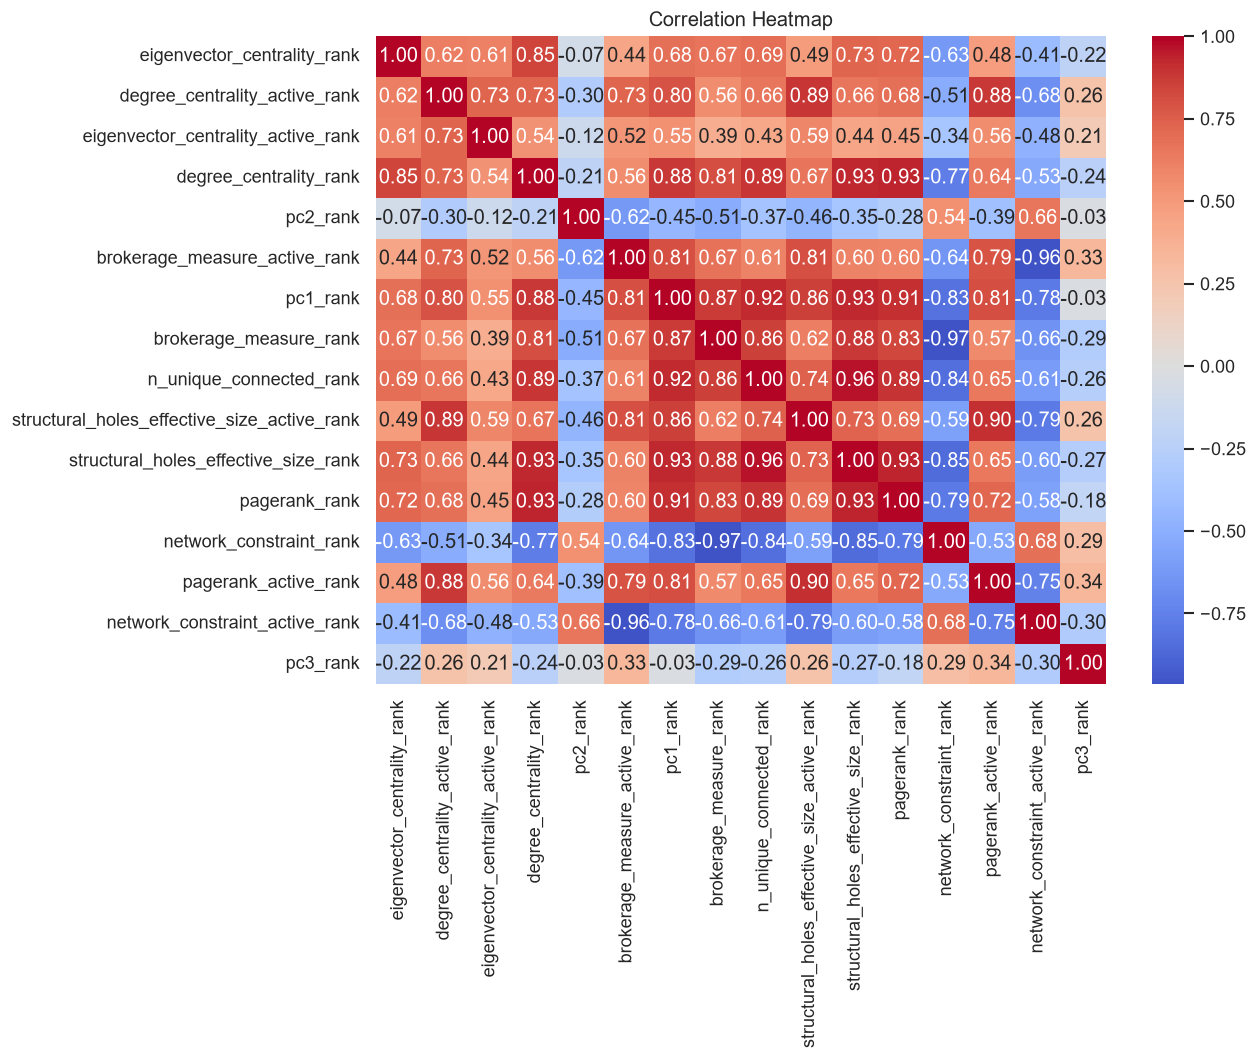

In [13]:
from ceo_sc.viz.plots import plot_correlation_heatmap

panel = pd.read_parquet(os.path.join(OUT, 'panel_with_returns.parquet'),
                         columns=[c for c in landscape.index] + ['year'])
sample = panel.sample(n=min(50_000, len(panel)), random_state=42)

fig, ax = plt.subplots(figsize=(11, 9))
plot_correlation_heatmap(sample[list(landscape.index)], ax=ax)
plt.tight_layout()
plt.show()

## 8. Summary

In [14]:
summary_cols = ['category', 'mean_rank_ic', 'rank_icir', 'long_short_sharpe',
                'long_short_ann_return', 't_stat', 'p_value']
top5 = landscape[summary_cols].round(4).head(5)
print('Top 5 factors by long-short Sharpe ratio:')
display(top5)

n_sig_uni = (landscape['p_value'] < 0.05).sum()
print(f"\n{n_sig_uni}/{len(landscape)} factors are significant (p < 0.05) in univariate Fama-MacBeth.")
print(f"{n_sig}/{len(mv_factors)} factors remain significant in the multivariate specification.")
print(f"\nBest single factor:   {best_factor} (Sharpe={landscape.loc[best_factor, 'long_short_sharpe']:.2f})")
print(f"PCA composite (PC1):   pc1_rank (Sharpe={landscape.loc['pc1_rank', 'long_short_sharpe']:.2f}), "
      f"explains {explained['pc1']:.1%} of factor variance")
print(f"\nWhole-universe benchmark annualized volatility: {risk['volatility_annualized']:.2%}")

Top 5 factors by long-short Sharpe ratio:


,category,mean_rank_ic,rank_icir,long_short_sharpe,long_short_ann_return,t_stat,p_value
factor,,,,,,,
eigenvector_centrality_rank,Cumulative,0.0075,0.1231,0.3747,0.0801,1.7982,0.0721
degree_centrality_active_rank,Active,0.0283,0.7358,0.3122,0.0725,1.6500,0.0990
eigenvector_centrality_active_rank,Active,0.0103,0.1623,0.2945,0.0591,1.3291,0.1838
degree_centrality_rank,Cumulative,0.0244,0.6240,0.2766,0.0682,1.5540,0.1202
pc2_rank,PCA composite,-0.0090,-0.2724,0.2686,0.0186,1.3597,0.1739



0/16 factors are significant (p < 0.05) in univariate Fama-MacBeth.
1/16 factors remain significant in the multivariate specification.

Best single factor:   eigenvector_centrality_rank (Sharpe=0.37)
PCA composite (PC1):   pc1_rank (Sharpe=0.19), explains 57.9% of factor variance

Whole-universe benchmark annualized volatility: 4.62%
